# Imports modules

In [ ]:
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

warnings.simplefilter(action='ignore', category=FutureWarning)

# Define paths

In [2]:
project_root = Path("/path/to/gmhcira") # Adjust these paths to match your local setup
output_root = Path("/path/to/gmhcira_outputs") # Adjust these paths to match your local setup

# Input data
admin_path = project_root / "data" / "gadm" / "gadm_410-levels.gpkg"
vuln_path = project_root / "data" / "Vulnerability"

# Intermediate/output data
damage_data_path = output_root / "damage"
extracts_data_path = output_root / "extracts"
output_risk_path = output_root / "protection_sensitivity"

# Figures
figures_path = output_root / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

# Settings

In [ ]:
hazard_types = ['fluvial', 'pluvial', 'coastal', 'earthquake', 'landslide_rf', 'landslide_eq', 'windstorm'] 

cis_dict = {
    "energy": {"power": ["transmission_line","distribution_line","cable","plant","substation",
                        "power_tower","power_pole"]},
    "transportation": {"road":  ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential', 'road', 'track' ], 
                        "air": ["airport", "runway", "terminal"],
                        "rail": ["railway"]}, 
    "water": {"water_supply": ["water_tower", "water_well", "reservoir_covered",
                                "water_treatment_plant", "water_storage_tank"]},
    "waste": {"waste_solid": ["waste_transfer_station"],
            "waste_water": ["wastewater_treatment_plant"]},
    "telecommunication": {"telecom": ["communication_tower", "mast"]},
    "healthcare": {"healthcare": ["clinic", "doctors", "hospital", "dentist", "pharmacy", 
                        "physiotherapist", "alternative", "laboratory", "optometrist", "rehabilitation", 
                        "blood_donation", "birthing_center"]},
    "education": {"education": ["college", "kindergarten", "library", "school", "university"]}
    }


In [4]:
# Read risk data
protection_standards = [0, 10, 50, 100, 250, 475, 975]
sheet_lst = hazard_types + ['multi-hazard']

sensitivity_dct = {}

for ds_standard in protection_standards:
    file_path = (output_risk_path / f'summary_with_1in{ds_standard}cutoff' / 'global_infra_risk.xlsx')
    sensitivity_dct[ds_standard] = pd.read_excel(file_path, sheet_name=sheet_lst)
    print(f'Loading done for {ds_standard}')

Loading done for 0
Loading done for 10
Loading done for 50
Loading done for 100
Loading done for 250
Loading done for 475
Loading done for 975


# Create appendix figure: design standards

In [5]:
# Extract global risk per design standard and hazard
global_risk_lst = []

for ds_standard, hazard_dict in sensitivity_dct.items():
    for hazard_type, df in hazard_dict.items():
        global_risk_lst.append({
            'design_standard': ds_standard,
            'hazard_type': hazard_type,
            'global_Q1': df['total_Q1'].sum(),
            'global_Q2': df['total_Q2'].sum(),
            'global_Q3': df['total_Q3'].sum()
        })

# Convert to DataFrame
global_risk_df = pd.DataFrame(global_risk_lst)

# Sort for convenience
global_risk_df = global_risk_df.sort_values(['hazard_type', 'design_standard']).reset_index(drop=True)

global_risk_df

,design_standard,hazard_type,global_Q1,global_Q2,global_Q3
0,0,coastal,1.754718e+10,4.902587e+10,6.228163e+10
1,10,coastal,6.597562e+09,1.823462e+10,2.313865e+10
2,50,coastal,3.152417e+09,9.051932e+09,1.144519e+10
3,100,coastal,2.034808e+09,6.028361e+09,7.614492e+09
4,250,coastal,1.058166e+09,3.255495e+09,4.108489e+09
5,475,coastal,7.730914e+08,2.400260e+09,3.028563e+09
6,975,coastal,4.095685e+08,1.283704e+09,1.619678e+09
7,0,earthquake,3.869633e+12,4.817850e+12,6.404033e+12
8,10,earthquake,4.223086e+11,5.221197e+11,6.938371e+11
9,50,earthquake,1.306666e+11,1.592305e+11,2.093529e+11


In [6]:
global_risk_df['lower_error'] = (global_risk_df['global_Q2'] - global_risk_df['global_Q1'])
global_risk_df['upper_error'] = (global_risk_df['global_Q3'] - global_risk_df['global_Q2'])
risk_cols = ['global_Q1','global_Q2', 'global_Q3', 'lower_error', 'upper_error']
global_risk_df[risk_cols] /= 1e9

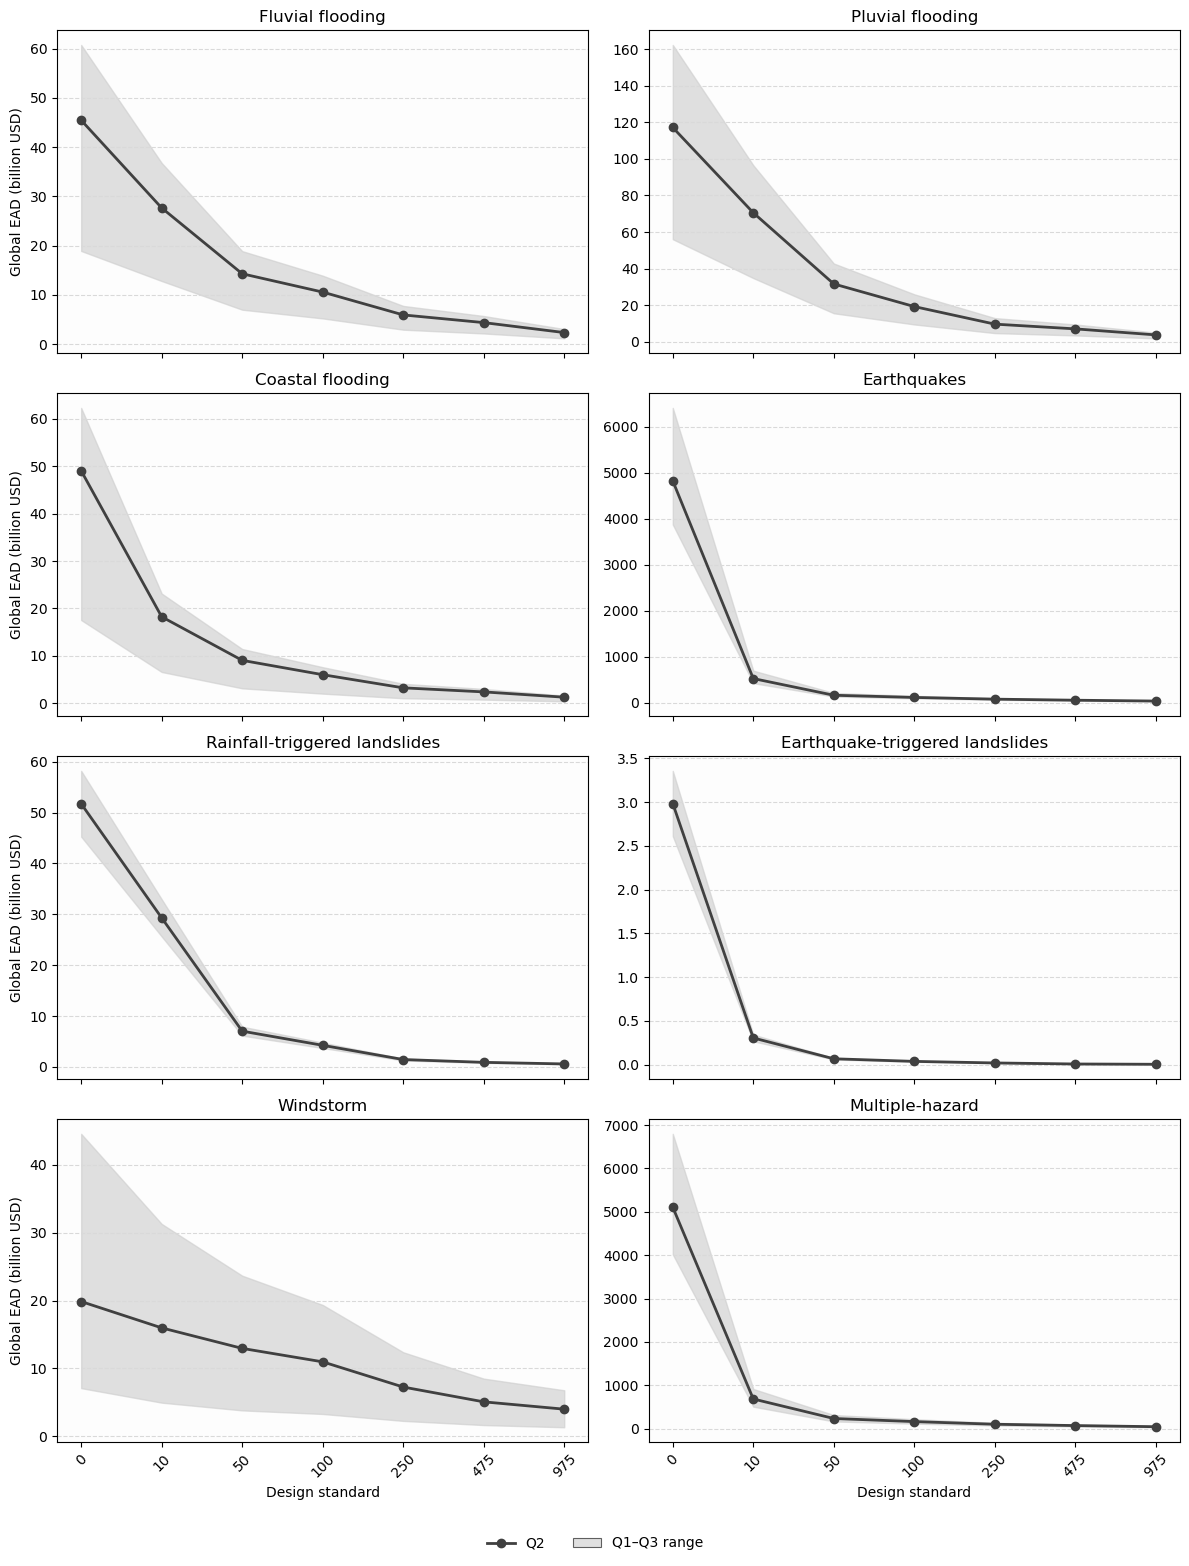

In [7]:
# Order of panels
hazard_order = hazard_types + ['multi-hazard']

# Panel titles
hazard_name_dct = {
    "fluvial": "Fluvial flooding",
    "pluvial": "Pluvial flooding",
    "coastal": "Coastal flooding",
    "earthquake": "Earthquakes",
    "landslide_rf": "Rainfall-triggered landslides",
    "landslide_eq": "Earthquake-triggered landslides",
    "windstorms": "Tropical cyclones",
    "multi-hazard": "Multiple-hazard"}

# Figure layout
ncols = 2
nrows = 4  
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 16), sharex=True, sharey=False)
axes = axes.flatten()

# x positions (equally spaced) and labels
x_labels = protection_standards
x_pos = np.arange(len(x_labels))

for i, hazard in enumerate(hazard_order):
    ax = axes[i]
    
    # Subset and sort
    sub = (global_risk_df[global_risk_df['hazard_type'] == hazard].sort_values('design_standard').copy())
    
    # Skip if hazard is missing
    if sub.empty:
        ax.axis('off')
        continue
    
    # Extract y-values
    y_q1 = sub['global_Q1'].values
    y_q2 = sub['global_Q2'].values
    y_q3 = sub['global_Q3'].values

    ax.set_facecolor('#fdfdfd')  # very light grey facecolor
    ax.fill_between(x_pos, y_q1, y_q3, color='0.8', alpha=0.6, label='Q1–Q3 range') # Uncertainty band
    ax.plot(x_pos, y_q2, color='0.25', marker='o', linewidth=2, label='Q2') # Central estimate
    ax.grid(True, axis='y', color='0.85', linestyle='--', linewidth=0.8) # Grid
    ax.set_title(hazard_name_dct.get(hazard, hazard.replace('_', ' ').title())) # Panel title
    
    # X-axis
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45)
    
    # Y-axis label only on left column
    if i % ncols == 0:
        ax.set_ylabel('Global EAD (billion USD)')
    
    # X-axis label only on bottom row
    if i >= len(axes) - ncols:
        ax.set_xlabel('Design standard')

# Turn off unused axes if needed
for j in range(len(hazard_order), len(axes)):
    axes[j].axis('off')

# Add one shared legend
legend_handles = [Line2D([0], [0], color='0.25', marker='o', linewidth=2, label='Q2'), 
                  Patch(facecolor='0.8', edgecolor='black', linewidth=0.8, alpha=0.6, label='Q1–Q3 range')]

fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

fig.savefig(figures_path / "FigureA2_sensitivity.png", dpi=300, bbox_inches="tight")

## data analysis

In [8]:
# Percentage decrease in global risk relative to design standard = 0
for hazard_type in global_risk_df['hazard_type'].unique():
    sub = global_risk_df[global_risk_df['hazard_type'] == hazard_type].sort_values('design_standard').copy()
    baseline_risk = sub.loc[sub['design_standard'] == 0, 'global_Q2'].iloc[0]
    previous_decrease = 0

    print(f'\n{hazard_type}')
    for _, row in sub.iterrows():
        percentage_decrease = (baseline_risk - row['global_Q2']) / baseline_risk * 100
        delta = percentage_decrease - previous_decrease

        if row['design_standard'] == 0:
            print(f"Design standard {int(row['design_standard']):>3}: {percentage_decrease:5.1f}% decrease")
        else:
            print(f"Design standard {int(row['design_standard']):>3}: {percentage_decrease:5.1f}% decrease; delta {delta:.1f}%")

        previous_decrease = percentage_decrease


coastal
Design standard   0:   0.0% decrease
Design standard  10:  62.8% decrease; delta 62.8%
Design standard  50:  81.5% decrease; delta 18.7%
Design standard 100:  87.7% decrease; delta 6.2%
Design standard 250:  93.4% decrease; delta 5.7%
Design standard 475:  95.1% decrease; delta 1.7%
Design standard 975:  97.4% decrease; delta 2.3%

earthquake
Design standard   0:   0.0% decrease
Design standard  10:  89.2% decrease; delta 89.2%
Design standard  50:  96.7% decrease; delta 7.5%
Design standard 100:  97.7% decrease; delta 1.0%
Design standard 250:  98.5% decrease; delta 0.8%
Design standard 475:  98.9% decrease; delta 0.5%
Design standard 975:  99.3% decrease; delta 0.4%

fluvial
Design standard   0:   0.0% decrease
Design standard  10:  39.2% decrease; delta 39.2%
Design standard  50:  68.6% decrease; delta 29.4%
Design standard 100:  76.8% decrease; delta 8.2%
Design standard 250:  87.0% decrease; delta 10.2%
Design standard 475:  90.5% decrease; delta 3.4%
Design standard 975:

In [9]:
# Percentage decrease in global risk relative to previous design standard
for hazard_type in global_risk_df['hazard_type'].unique():
    sub = global_risk_df[global_risk_df['hazard_type'] == hazard_type].sort_values('design_standard').copy()
    sub['previous_standard'] = sub['design_standard'].shift(1)
    sub['previous_Q2'] = sub['global_Q2'].shift(1)
    sub['percentage_decrease'] = (sub['previous_Q2'] - sub['global_Q2']) / sub['previous_Q2'] * 100

    print(f'\n{hazard_type}')
    for _, row in sub.dropna(subset=['previous_Q2']).iterrows():
        print(
            f"{int(row['previous_standard'])} → {int(row['design_standard'])}: "
            f"{row['previous_Q2']:.1f} → {row['global_Q2']:.1f} billion USD, "
            f"{row['percentage_decrease']:.1f}% decrease"
        )


coastal
0 → 10: 49.0 → 18.2 billion USD, 62.8% decrease
10 → 50: 18.2 → 9.1 billion USD, 50.4% decrease
50 → 100: 9.1 → 6.0 billion USD, 33.4% decrease
100 → 250: 6.0 → 3.3 billion USD, 46.0% decrease
250 → 475: 3.3 → 2.4 billion USD, 26.3% decrease
475 → 975: 2.4 → 1.3 billion USD, 46.5% decrease

earthquake
0 → 10: 4817.9 → 522.1 billion USD, 89.2% decrease
10 → 50: 522.1 → 159.2 billion USD, 69.5% decrease
50 → 100: 159.2 → 111.9 billion USD, 29.8% decrease
100 → 250: 111.9 → 74.5 billion USD, 33.4% decrease
250 → 475: 74.5 → 51.4 billion USD, 31.0% decrease
475 → 975: 51.4 → 33.2 billion USD, 35.5% decrease

fluvial
0 → 10: 45.5 → 27.6 billion USD, 39.2% decrease
10 → 50: 27.6 → 14.3 billion USD, 48.4% decrease
50 → 100: 14.3 → 10.5 billion USD, 26.1% decrease
100 → 250: 10.5 → 5.9 billion USD, 44.0% decrease
250 → 475: 5.9 → 4.3 billion USD, 26.4% decrease
475 → 975: 4.3 → 2.3 billion USD, 46.6% decrease

landslide_eq
0 → 10: 3.0 → 0.3 billion USD, 89.8% decrease
10 → 50: 0.3 → 0